In [173]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.mixture import GaussianMixture
from matplotlib import pyplot as plt
import seaborn as sns

In [181]:
iris = load_iris()

df= pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                 columns= iris['feature_names'] + ['target'])
df.drop("target", axis=1, inplace=True)
df['label'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df_x = df.drop("label", axis=1)
min_max_scaler = preprocessing.StandardScaler()
#df_x = min_max_scaler.fit_transform(df_x)
#df_x = pd.DataFrame(df_x, columns=df.columns[:-1])
df_x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [185]:
print("Part1.")
iterations = 100
best_score = np.inf
previous_best = np.inf
for i in range(iterations):
    kmeans = KMeans(n_clusters=3, n_init=1).fit(df_x)
    _score = kmeans.inertia_
    if _score < best_score:
        print(f"Iteration {i}: finds better clustering, latest reconstruction error is: {_score}")
        previous_best = best_score
        best_score = _score
    if (previous_best - best_score) / best_score < 0.01:
        print("Score diff smaller than 1%, stop.")
        break

Part1.
Iteration 0: finds better clustering, latest reconstruction error is: 78.85566582597727
Iteration 2: finds better clustering, latest reconstruction error is: 78.851441426146
Score diff smaller than 1%, stop.


Use 2 as n_init


([<matplotlib.axis.XTick at 0x12ed858d0>,
 <a list of 19 Text major ticklabel objects>)

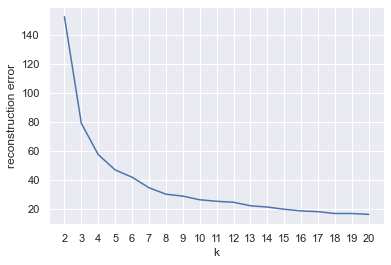

In [186]:
print("Use 2 as n_init")
re_errors = []
k_range = list(range(2, 21))
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=2).fit(df_x)
    re_errors.append(kmeans.inertia_)

sns.set()
plt.plot(k_range, re_errors)
plt.xlabel("k")
plt.ylabel("reconstruction error")
plt.xticks(k_range)

In [187]:
print("elbow_k found manually would be: 8. Try to do it algorithmically by calculating the speed of reconstruction error decline")
print("Finding elbow k programatically...")
ratios = []
for idx, re_error in enumerate(re_errors):
    if idx == len(re_errors) - 1:
        break
    ratios.append((re_errors[idx] - re_errors[idx + 1]) / re_errors[idx])
print("Decline ratios calculated.")

decline_thld = (round(max(re_errors) / 9) / 2) / 100
win_start = 0
win_size = 5
for idx, ratio in enumerate(ratios):
    print(f"inspecting no.{idx} in raios")
    if win_start + win_size > len(ratios):
        print("idx exceeding array index, stop!")
        break
    ratio_in_window = [r for _idx, r in enumerate(ratios[win_start: win_start + win_size])]
    ratio_gt_thld = [r > decline_thld for r in ratio_in_window]
    if sum(ratio_gt_thld) < win_size / 2:
        print(f"valid ratio counts inside window: {sum(ratio_gt_thld)}, less than a half. Stop!")
        break
    else:
        win_start += 1

# the center of the window is the exact point we want
win_mid = win_start + 2
print(f"Found the elbow idx in ratios: {win_mid}, transforming to k...")
# decode the window idx back to k, since window idx starts from 0, while k starts from 2.
elbow_k_by_algorithm = k_range[win_mid + 1]
print(f"The elbow k found: {elbow_k_by_algorithm}")

elbow_k found manually would be: 8. Try to do it algorithmically by calculating the speed of reconstruction error decline
Finding elbow k programatically...
Decline ratios calculated.
inspecting no.0 in raios
inspecting no.1 in raios
inspecting no.2 in raios
inspecting no.3 in raios
inspecting no.4 in raios
inspecting no.5 in raios
valid ratio counts inside window: 2, less than a half. Stop!
Found the elbow idx in ratios: 7, transforming to k...
The elbow k found: 10


In [188]:
kmeans = KMeans(n_clusters=elbow_k_by_algorithm).fit(df_x)
df_kmeans = df.copy()
df_kmeans["kmeans"] = kmeans.predict(df_x)

print("Cannot calculate Accuracy Score because the number of classes is not the same as the number of clusters")
#df_kmeans

Cannot calculate Accuracy Score because the number of classes is not the same as the number of clusters


In [189]:
cm = []
clusters = sorted(df_kmeans["kmeans"].unique())
labels = df_kmeans["label"].unique()
for label in labels:
    _row = []
    _df = df_kmeans[df_kmeans["label"]==label]
    for c in clusters:
        _row.append(len(_df[_df["kmeans"]==c]))
    cm.append(_row)

df_cm = pd.DataFrame(cm, columns=[f"cluster{c}" for c in clusters])
df_cm.index = labels
print(f"confusion matrix:\n {df_cm}")

confusion matrix:
             cluster0  cluster1  cluster2  cluster3  cluster4  cluster5  \
setosa             0        13         0         0         0         0   
versicolor         0         0        22         0         3        18   
virginica         21         0         1         6        15         0   

            cluster6  cluster7  cluster8  cluster9  
setosa            19         0         0        18  
versicolor         0         0         7         0  
virginica          0         7         0         0  


In [190]:
kmeans = KMeans(n_clusters=3).fit(df_x)
df_kmeans = df_x.copy()
df_kmeans["kmeans"] = kmeans.predict(df_x)
df_kmeans["label"] = df["label"]
df_kmeans

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),kmeans,label
0,5.1,3.5,1.4,0.2,1,setosa
1,4.9,3.0,1.4,0.2,1,setosa
2,4.7,3.2,1.3,0.2,1,setosa
3,4.6,3.1,1.5,0.2,1,setosa
4,5.0,3.6,1.4,0.2,1,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,0,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [191]:
cm = []
clusters = sorted(df_kmeans["kmeans"].unique())
labels = df_kmeans["label"].unique()
for label in labels:
    _row = []
    _df = df_kmeans[df_kmeans["label"]==label]
    for c in clusters:
        _row.append(len(_df[_df["kmeans"]==c]))
    cm.append(_row)

df_cm = pd.DataFrame(cm, columns=[f"cluster{c}" for c in clusters])
df_cm.index = labels
print(f"confusion matrix:\n {df_cm}")

confusion matrix:
             cluster0  cluster1  cluster2
setosa             0        50         0
versicolor        48         0         2
virginica         14         0        36


In [192]:
print(f"Accuracy score: {(50+48+36) / len(df_kmeans)}")

Accuracy score: 0.8933333333333333


In [114]:
df_cm

,cluster0,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,cluster7,cluster8
setosa,0,23,0,0,0,0,0,19,8
versicolor,11,0,0,4,16,0,19,0,0
virginica,0,0,22,15,1,12,0,0,0


Q1.
In my elbow_k kmeans results, 3 species are included. Cluster1, 6 and 9 represents setosa, cluster2, 5 and 8 represents versicolor. While cluster cluster0, 3, 4 and 7 represents virginica.


In [193]:
print("Part2.")
iterations = 100
best_score = np.inf
previous_best = np.inf
for i in range(iterations):
    gmm = GaussianMixture(n_components=3, n_init=1)
    gmm.fit(df_x)
    _score = gmm.lower_bound_
    if _score < best_score:
        print(f"Iteration {i}: found better lower_bound_ score: {_score}")
        previous_best = best_score
        best_score = _score
    if previous_best != np.inf and (previous_best - best_score) / best_score < 0.01:
        print("Score diff smaller than 1%, stop.")
        break

Part2.
Iteration 0: found better lower_bound_ score: -1.2014746139064725
Iteration 44: found better lower_bound_ score: -1.2014746139064734
Score diff smaller than 1%, stop.


Use 2 as n_init for GMM.


([<matplotlib.axis.XTick at 0x12ef34d68>,
 <a list of 19 Text major ticklabel objects>)

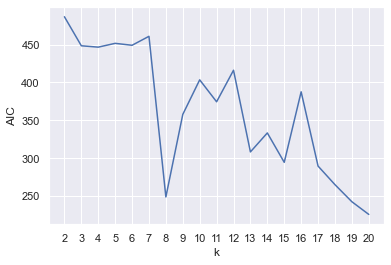

In [194]:
print("Use 2 as n_init for GMM.")
aics = []
k_range = list(range(2, 21))
for k in k_range:
    gmm = GaussianMixture(n_components=k, n_init=2).fit(df_x)
    aics.append(gmm.aic(df_x))

sns.set()
plt.plot(k_range, aics)
plt.xlabel("k")
plt.ylabel("AIC")
plt.xticks(k_range)

In [195]:
print("The elbow of the curve (aic_elbow_k): 8")

The elbow of the curve (aic_elbow_k): 8


([<matplotlib.axis.XTick at 0x12efe22e8>,
 <a list of 19 Text major ticklabel objects>)

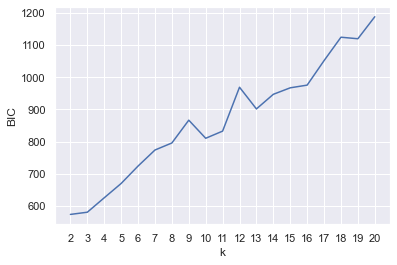

In [196]:
bics = []
k_range = list(range(2, 21))
for k in k_range:
    gmm = GaussianMixture(n_components=k, n_init=2).fit(df_x)
    bics.append(gmm.bic(df_x))

sns.set()
plt.plot(k_range, bics)
plt.xlabel("k")
plt.ylabel("BIC")
plt.xticks(k_range)

In [141]:
print("The elbow of the curve (bic_elbow_k): 2")

The elbow of the curve (bic_elbow_k): 2


In [197]:
print("Predict using k=aic_elbow_k (8)")
gmm = GaussianMixture(n_components=8, n_init=2).fit(df_x)
df_gmm = df.copy()
df_gmm["gmm"] = gmm.predict(df_x)
print("Cannot calculate Accuracy Score because the number of classes is not the same as the number of clusters")

Predict using k=aic_elbow_k (8)
Cannot calculate Accuracy Score because the number of classes is not the same as the number of clusters


In [198]:
# confusion matrix for GMM
cm = []
clusters = sorted(df_gmm["gmm"].unique())
labels = df_gmm["label"].unique()
for label in labels:
    _row = []
    _df = df_gmm[df_gmm["label"]==label]
    for c in clusters:
        _row.append(len(_df[_df["gmm"]==c]))
    cm.append(_row)

df_cm = pd.DataFrame(cm, columns=[f"cluster{c}" for c in clusters])
df_cm.index = labels
print(f"confusion matrix:\n {df_cm}")

confusion matrix:
             cluster0  cluster1  cluster2  cluster3  cluster4  cluster5  \
setosa            15         0         0         0         0        35   
versicolor         0         9         1        21         4         0   
virginica          0        12        25         1         0         0   

            cluster6  cluster7  
setosa             0         0  
versicolor        15         0  
virginica          0        12  


In [199]:
df_cm

,cluster0,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,cluster7
setosa,15,0,0,0,0,35,0,0
versicolor,0,9,1,21,4,0,15,0
virginica,0,12,25,1,0,0,0,12


In [147]:
print("Predict using k=bic_elbow_k (2)")
gmm2 = GaussianMixture(n_components=2, n_init=2).fit(df_x)
df_gmm2 = df.copy()
df_gmm2["gmm"] = gmm2.predict(df_x)
print("Cannot calculate Accuracy Score because the number of classes is not the same as the number of clusters")

# confusion matrix for GMM
cm = []
clusters = sorted(df_gmm2["gmm"].unique())
labels = df_gmm2["label"].unique()
for label in labels:
    _row = []
    _df = df_gmm2[df_gmm2["label"]==label]
    for c in clusters:
        _row.append(len(_df[_df["gmm"]==c]))
    cm.append(_row)

df_cm = pd.DataFrame(cm, columns=[f"cluster{c}" for c in clusters])
df_cm.index = labels
print(f"confusion matrix:\n {df_cm}")

Predict using k=bic_elbow_k (2)
Cannot calculate Accuracy Score because the number of classes is not the same as the number of clusters
confusion matrix:
             cluster0  cluster1
setosa            50         0
versicolor         0        50
virginica          0        50


In [148]:
print("Predict using k=2")
gmm3 = GaussianMixture(n_components=3, n_init=2).fit(df_x)
df_gmm3 = df.copy()
df_gmm3["gmm"] = gmm3.predict(df_x)

# confusion matrix for GMM
cm = []
clusters = sorted(df_gmm3["gmm"].unique())
labels = df_gmm3["label"].unique()
for label in labels:
    _row = []
    _df = df_gmm3[df_gmm3["label"]==label]
    for c in clusters:
        _row.append(len(_df[_df["gmm"]==c]))
    cm.append(_row)

df_cm = pd.DataFrame(cm, columns=[f"cluster{c}" for c in clusters])
df_cm.index = labels
print(f"confusion matrix:\n {df_cm}")

Predict using k=2
confusion matrix:
             cluster0  cluster1  cluster2
setosa             0        50         0
versicolor        45         0         5
virginica          0         0        50


In [149]:
print(f"Accuracy score: {(50+45+50) / len(df_gmm3)}")

Accuracy score: 0.9666666666666667


Q 2a.
In the AIC results, 3 species of iris are represented. Cluster0, and 5 represents setosa, cluster3, 4 and 6 represents versicolor. While cluster cluster1, 2, and 7 represents virginica.

Q 2b.
In the BIC results, only 2 species of iris are represented. Cluster 0 represents setosa, while cluster 1 represents the combination of versicolor and virginica.